In [1]:
import torch
import numpy as np

from PycalcAct.dataset import Dataset
from PycalcAct.model import (
    MixedFCTemporalModel,
)
from PycalcAct.trainer import Trainer
_ = torch.manual_seed(1234)

In [ ]:
trainingData = 'D:\\Ca2-Analysis_McGill\\dataExport\\'
dataset = Dataset(
    csv_path=trainingData+"legend.csv",
    csv_pos_path=trainingData+"position.csv",  # Optional
    position_to_displacement=True
    # Convert the x, y position to a single displacement value (sqrt((x(t+1)-x(t))^2 + (y(t+1)-y(t))^2)
)
model = MixedFCTemporalModel(
    n_classes=dataset.n_classes,
    temporal_length=dataset.length_serie,
    input_size=dataset.features,
)
n_epochs = 750
model.load_state_dict(torch.load("D:\sebastien\PycalcActivation\models\simpleMcGillModel", weights_only=True))
trainer = Trainer(
    dataset, model, device="cuda"
) 

In [5]:
trainer.model.load_state_dict(torch.load("D:\sebastien\PycalcActivation\models\simpleMcGillModel", weights_only=True))
display(trainer.model.final_layer.weight)

Parameter containing:
tensor([[ 1.1485e-01,  4.7863e-02,  1.4490e-01, -4.8423e-03,  1.1841e-01,
          3.5711e-02, -2.7876e-02, -4.9112e-02, -1.4684e-01,  6.6637e-02,
          1.3239e-01, -1.3217e-01,  4.3743e-02, -5.7156e-02,  1.3045e-01,
          1.8784e-01, -2.2706e-01, -2.0091e-01, -2.3501e-01,  1.1730e-01,
          3.4077e-02,  2.3060e-01, -1.2036e-02,  1.2698e-01, -3.4765e-02,
          4.7070e-02,  1.2034e-01,  2.5284e-02, -1.5688e-01,  2.7194e-01,
         -4.4068e-02, -1.7576e-01, -1.5045e-02, -1.8273e-01,  7.2007e-02,
         -9.8182e-04,  3.4682e-02, -9.7898e-02,  6.0506e-02, -2.0200e-01,
         -3.4756e-02,  2.1337e-02,  9.0171e-02,  1.1603e-01,  4.8196e-03,
         -7.4042e-02,  6.3659e-02,  1.1817e-05,  3.2222e-03, -1.7658e-01,
         -2.3715e-02, -6.5800e-02,  1.0428e-01,  1.6903e-02,  6.9564e-02,
         -8.3878e-05, -1.5115e-01,  1.1440e-01, -1.6486e-01,  1.4014e-02,
          9.0064e-02,  1.0387e-01, -1.3828e-01, -1.3604e-01],
        [ 4.3540e-02, -1.640

In [3]:
trainer.summary(optimizer=False, model=True, data=True)

Model
Layer (type:depth-idx)                   Output Shape              Param #
MixedFCTemporalModel                     [10, 4]                   --
├─GRU: 1-1                               [10, 120, 64]             25,728
├─Sequential: 1-2                        [10, 64]                  --
│    └─Sequential: 2-1                   [10, 64]                  --
│    │    └─Linear: 3-1                  [10, 64]                  491,584
│    │    └─ReLU: 3-2                    [10, 64]                  --
│    │    └─Dropout1d: 3-3               [10, 64]                  --
│    └─Sequential: 2-2                   [10, 64]                  --
│    │    └─Linear: 3-4                  [10, 64]                  4,160
│    │    └─ReLU: 3-5                    [10, 64]                  --
│    │    └─Dropout1d: 3-6               [10, 64]                  --
├─Linear: 1-3                            [10, 4]                   260
Total params: 521,732
Trainable params: 521,732
Non-trainable para

,Total,N4,Q4,Q4H7,T4
Train,16084,6144,4790,2299,2851
Validation,4022,1536,1198,575,713
Test,5027,1920,1497,719,891
Total,25133,9600,7485,3593,4455


In [ ]:
# trainer.train(n_epochs)


╭───────────────────────────┬───────────────────────────┬───────────────────────────╮
│           Epoch           │                      Loss │                  Accuracy │
├───────────────────────────┼───────────────────────────┼───────────────────────────┤
│             0             │                      1.39 │                     40.03 │
│             3             │                      1.36 │                     43.09 │
│             10            │                      1.28 │                     47.04 │
│             11            │                      1.29 │                     47.14 │
│             16            │                      1.27 │                     48.26 │
│             22            │                      1.27 │                     48.76 │
│             23            │                      1.26 │                     49.08 │
│             29            │                      1.25 │                     49.40 │
│             41            │                      1.2

D:\sebastien\PycalcActivation\src\PycalcAct\trainer.py:201: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
D:\sebastien\PycalcActivation\src\PycalcAct\trainer.py:201: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


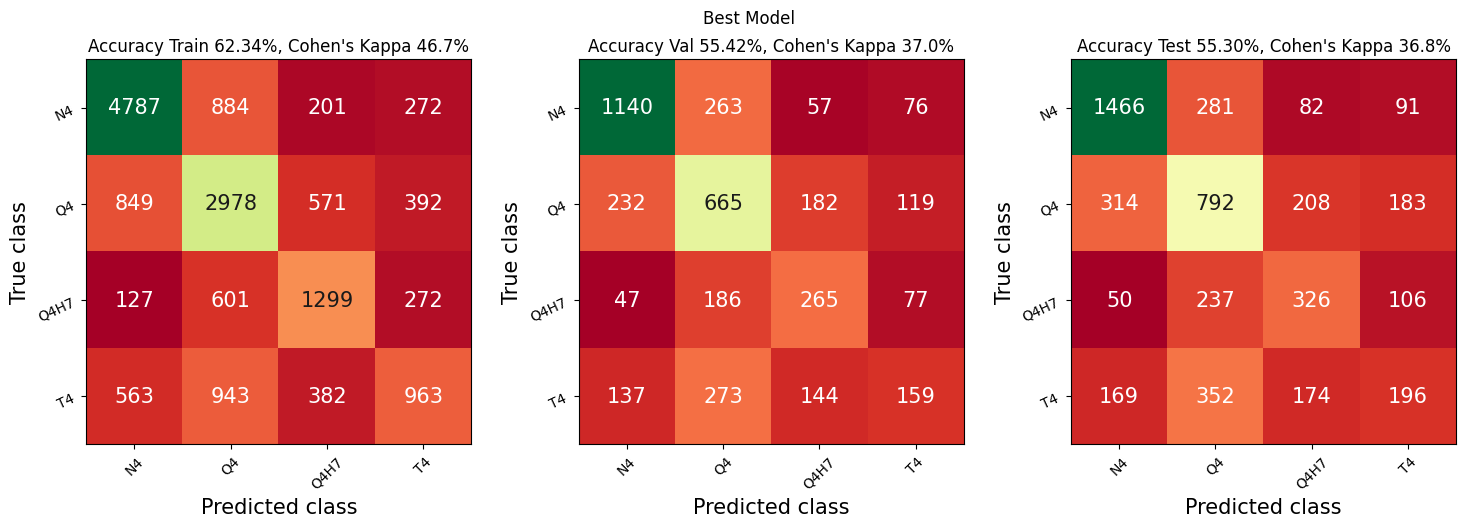

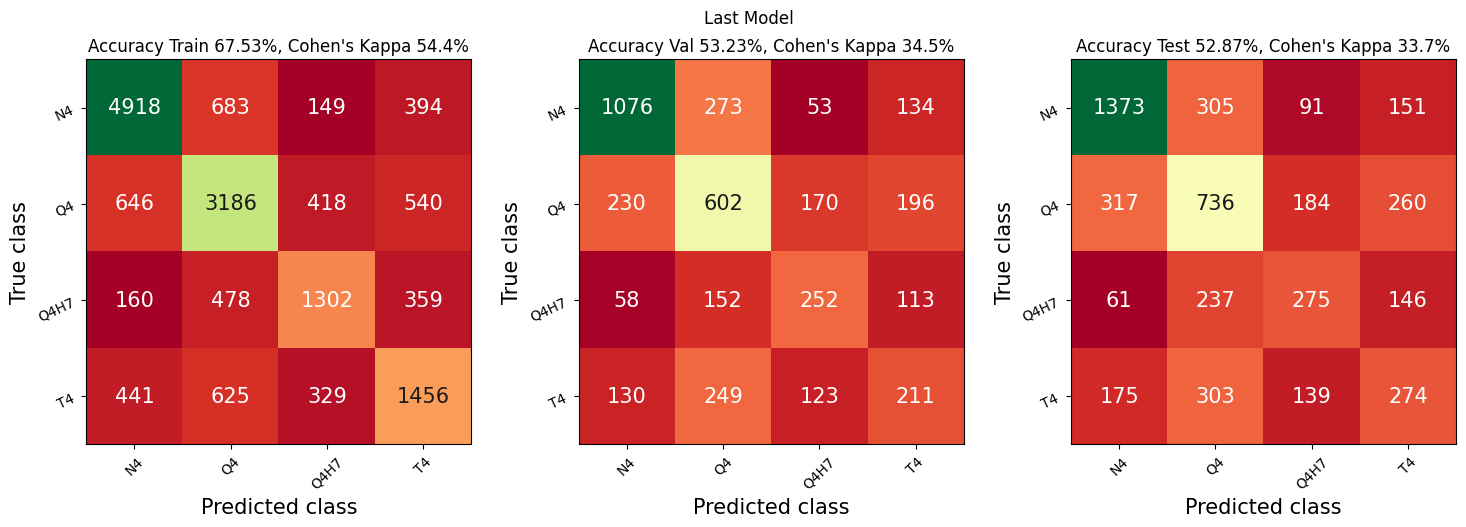

In [ ]:
trainer.test("best")  # Testing on the best model (in term of validation accuracy)
trainer.test("last")
# torch.save(trainer.model.state_dict(), "D:\sebastien\PycalcActivation\models\simpleMcGillModel")

In [6]:
validationData = 'D:\Ca2-Analysis_McGill\\dataExport\\validationMcGill\\'
datasetHMR = Dataset(
    csv_path=validationData+"legend.csv",
    csv_pos_path=validationData+"position.csv",  # Optional
    position_to_displacement=True,
    # Convert the x, y position to a single displacement value (sqrt((x(t+1)-x(t))^2 + (y(t+1)-y(t))^2)
)


In [9]:
from PycalcAct.predictor import Predictor
predictorHMR = Predictor(
    datasetHMR, trainer.model, device="cuda"
) 
a,b = predictorHMR.dataset.batch_from_data(x = predictorHMR.dataset.data, 
                                           y = predictorHMR.dataset.classes_int,
                                           time_first=True, to_cuda = True)

In [21]:
predictorHMR.eval(a,b)

RuntimeError: weight tensor should be defined either for all 4 classes or no classes but got weight tensor of shape: [3]

In [33]:
predictorHMR.model.eval()
predictorHMR.metrics.reset()
predictorHMR.confmat.reset()
with torch.no_grad():
    y_pred = predictorHMR.model(a)
    # loss = predictorHMR.criterion(y_pred, y.long())
    # y_pred = torch.softmax(y_pred, dim=1)
    # predictorHMR.metrics(y_pred, y)
    # predictorHMR.confmat(y_pred, y)
y_pred


tensor([[  4.5719,  -0.7552,  -6.3698,   1.6381],
        [  1.3527,  -1.6551,  -3.2018,   1.4294],
        [  3.7973,   1.5089,  -5.7784,  -0.4556],
        ...,
        [ -2.4345,  -1.9582,   4.0956,  -1.4856],
        [  8.4892,  -2.4608, -10.8132,   2.2733],
        [  2.5184,   2.5582,   0.6262,  -4.5565]], device='cuda:0')

In [27]:
y_pred = predictorHMR.model(a)
y_pred = torch.softmax(y_pred, dim=1)
# predictorHMR.confmat(y_pred, b)
